In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Plotting
This notebook generates the plots in Dai et al 2025 using simulations generated in another notebook.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
from scipy.stats import chi2
import cloudpickle as pickle
from astropy.cosmology import FlatLambdaCDM
from ndtest import ks2d2s
from astropy.time import Time

from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from utils.plotting_utils import (plot_snr_distr, 
                                plot_logflux_vs_logfluxerr,
                                plot_logflux_vs_logfluxerr_corner,
                                plot_logmaxflux_vs_logmaxfluxerr,
                                plot_logmaxflux_vs_logmaxfluxerr_corner,
                                convert_flux_to_mag,
                                plot_mag_vs_magerr,
                                convert_flux_to_njy,
                                plot_flux_vs_fluxerr,
                                )

from ztf_snia_sim_params import SIM_PARAMS

from utils.analysis_utils import get_sn_host_sep


In [4]:
import matplotlib
matplotlib.style.use('seaborn-v0_8-paper')

In [5]:
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [6]:
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]

In [7]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [8]:
sndata.redshift.min(), sndata.redshift.max()

(0.00245848, 0.28779283)

In [9]:
len(sndata)

3628

In [10]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [11]:
t = Time([lcdata['lc.mjd'].min(),lcdata['lc.mjd'].max()], format='mjd', scale='utc')
print(t.to_datetime())

[datetime.datetime(2017, 11, 4, 13, 3, 38, 16000)
 datetime.datetime(2024, 4, 19, 8, 40, 14, 592000)]


In [12]:
lightcurves = read_parquet('results/lightcurves.parquet')

In [13]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})

In [14]:
t = Time([lightcurves['lc.mjd'].min(),lightcurves['lc.mjd'].max()], format='mjd', scale='utc')
print(t.to_datetime())

[datetime.datetime(2018, 6, 19, 4, 7, 30)
 datetime.datetime(2021, 2, 28, 13, 24, 22, 500000)]


In [15]:
lightcurves.head()

id          ra        dec  nobs            t0         z  \
0   0  155.461196  10.812117   411  59093.252822  0.147875   
1   1   74.734716  56.850038  1052   59120.26292  0.150867   
2   2  270.453856   7.358522   678  59171.744427  0.153315   
3   3  175.237605  27.749533   792  58664.600741  0.073493   
4   4   72.007917   4.181406   565  58804.928513  0.153977   

                                              params  source_x0  source_x1  \
0  {'DistModFromRedshift:_distmod_from_redshift_9...    0.00019   0.116075   
1  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000122  -0.476493   
2  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000039  -0.184232   
3  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000937   1.629252   
4  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000141  -0.492835   

   source_c  host_hostmass   source_ra  source_dec     host_ra   host_dec  \
0  0.005235      10.609704  155.461196   10.812117   155.46106  10.812113   
1  0.004102        10.6586   74.734716   56.850038   74.735692  56.850426   
2  0.426158      10.912789  270.453856    7.358522  270.453884   7.358718   
3  0.020544       8.163163  175.237605   27.749533  175.238046  27.750762   
4  -0.01491       9.527334   72.007917    4.181406   72.008002   4.181293   

                                                  lc pass_spec_selection  \
0  [{mjd: 58290.195312, filter: 'g', flux: -9155....               False   
1  [{mjd: 58307.480469, filter: 'g', flux: 3418.6...               False   
2  [{mjd: 58288.3125, filter: 'r', flux: -674.090...               False   
3  [{mjd: 58289.175781, filter: 'g', flux: 3337.4...                True   
4  [{mjd: 58334.480469, filter: 'g', flux: -3527....                True   

  pass_quality_cuts  
0             False  
1             False  
2             False  
3              True  
4             False

In [16]:
lightcurves['params'][0].keys()

dict_keys(['DistModFromRedshift:_distmod_from_redshift_9.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_9.redshift', 'NumpyRandomFunc:exponential_6.function_node_result', 'NumpyRandomFunc:exponential_6.scale', 'NumpyRandomFunc:normal_10.function_node_result', 'NumpyRandomFunc:normal_10.loc', 'NumpyRandomFunc:normal_10.scale', 'NumpyRandomFunc:uniform_7.function_node_result', 'NumpyRandomFunc:uniform_7.high', 'NumpyRandomFunc:uniform_7.low', 'SamplePDF:_rvs_4.function_node_result', 'host.dec', 'host.distance', 'host.hostmass', 'host.ra', 'host.redshift', 'host.t0', 'mwext.dec', 'mwext.ebv', 'mwext.ra', 'pznode.c', 'pznode.mass', 'pznode.x1', 'radec.dec', 'radec.ra', 'sncoor_node.dec', 'sncoor_node.host_dec', 'sncoor_node.host_ra', 'sncoor_node.physical_sep_kpc', 'sncoor_node.ra', 'sncoor_node.redshift', 'source.Rv', 'source.c', 'source.dec', 'source.distance', 'source.ebv', 'source.ra', 'source.redshift', 'source.t0', 'source.x0', 'source.x1', 'x0_func.alpha', 'x0_fu

In [17]:
print("All sample simulated: nsn=", len(lightcurves))
# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lc.is_saturated==False").dropna()
print("After dropping saturation: nsn=", len(lightcurves_after_drop_sat))
lightcurves_after_detection = lightcurves_after_drop_sat.query("lc.detection_flag == True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))
lightcurves_after_spec_selection = lightcurves.loc[lightcurves['pass_spec_selection']]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))
lightcurves_after_quality_cut = lightcurves.loc[lightcurves['pass_quality_cuts']]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

All sample simulated: nsn= 105272
After dropping saturation: nsn= 105272
After applying detection: nsn= 51482
After spectroscopic selection: nsn= 4733
After quality cuts: nsn= 3665


In [18]:
with open("results/saved_model_and_passband.pkl", "rb") as file:  
    lynx_model, passband_group = pickle.load(file)

<ArrowExtensionArray>
[64093]
Length: 1, dtype: int64[pyarrow]
x0 0.0003714365096589312
x1 0.8432196974754333
c -0.08319234848022461
z 0.12315883811234288
mwebv 0.007692094287503302


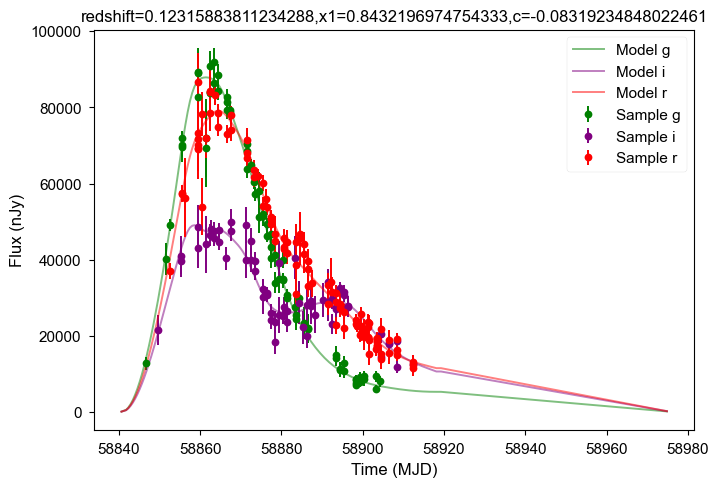

In [19]:
sncosmo_modelname = "salt3"
random_ids = lightcurves_after_quality_cut.id.sample(1).values
colormap = {'g':'g',
            'r':'r',
            'i':'purple',}
print(random_ids)

for random_id in random_ids:
    # Extract the row for this object.
    # lc = lightcurves.loc[lightcurves.id==random_id]
    lc = lightcurves_after_quality_cut.loc[lightcurves_after_quality_cut.id==random_id]
    lc = lc.query("lc.detection_flag==True")
    
    state = GraphState.from_dict(lc.iloc[0]["params"])
    noise_free_lcs = compute_single_noise_free_lightcurve(
        lynx_model,
        state,
        passband_group,
        rest_frame_phase_min=-20.0, 
        rest_frame_phase_max=100.0, 
        rest_frame_phase_step=0.5, 
    )
    
    if lc["nobs"].values[0] > 0:
        # Unpack the nested columns (filters, mjd, flux, and flux error).
        lc_filters = np.asarray(lc["lc.filter"], dtype=str)
        lc_mjd = np.asarray(lc["lc.mjd"], dtype=float)
        lc_flux = np.asarray(lc["lc.flux"], dtype=float)
        lc_fluxerr = np.asarray(lc["lc.fluxerr"], dtype=float)
        
        lc_mag = -2.5*np.log10(lc_flux) + 31.4
        lc_magerr = np.absolute(1.086*lc_fluxerr/lc_flux)
        
        plot_lightcurves(
            fluxes=lc_flux,
            times=lc_mjd,
            fluxerrs=lc_fluxerr,
            filters=lc_filters,
            colormap=colormap,
            underlying_model=noise_free_lcs,
        )
        plt.ylabel('Flux (nJy)')
        # plt.title(f"redshift={lc['z']},mwebv={lc['params'].values[0]['mwext.ebv']}")
        plt.title(f"redshift={lc['z'].values[0]},x1={lc['params'].values[0]['source.x1']},c={lc['params'].values[0]['source.c']}")
        for par in ['x0','x1','c']:
            print(par,lc['params'].values[0][f'source.{par}'])
        print('z',lc['z'].values[0])
        print('mwebv',lc['params'].values[0]['mwext.ebv'])
        
        model = sncosmo.Model(source=sncosmo_modelname,
                      effects=[sncosmo.F99Dust()],
                      effect_names=['mw'],
                      effect_frames=['obs'])
        pardict = {}
        for p in ['x0','x1','c','t0']:
            pardict[p] = lc['params'].values[0][f'source.{p}']
        pardict['mwebv'] = lc['params'].values[0]['mwext.ebv']
        pardict['z'] = lc['z'].values[0]
        model.update(pardict)
        obstime = noise_free_lcs["times"][1:-1]
        sncosmo_flux = {}
        lynx_flux = {}
        mjd = {}
                        
        # for b in 'gri':
        #     lynx_pb = passband_group.passbands[f'ZTF_{b}']
        #     wave = lynx_pb._loaded_table[:,0] #lynx_pb.processed_transmission_table[:,0]
        #     trans = lynx_pb._loaded_table[:,1] #lynx_pb.processed_transmission_table[:,1]
        #     pb = sncosmo.Bandpass(wave,trans)
        #     # pb = sncosmo.get_bandpass(f"ztf{b}")
        #     sncosmo_flux[b] = model.bandflux(pb,obstime,zp=31.4,zpsys='ab')
        #     plt.plot(obstime,sncosmo_flux[b],label=b,ls=':',color=colormap[b])
        #     lynx_flux[b] = noise_free_lcs[b][1:-1]
            
        plt.legend()
        plt.show()

        # for b in 'gri':
        #     plt.plot(obstime, lynx_flux[b] / sncosmo_flux[b],label=b)
        # plt.xlabel("time")
        # plt.ylabel("lynx_bandflux/sncosmo_bandflux")
        # plt.legend()
        
        # plot_lightcurves(
        #     fluxes=lc_mag,
        #     times=lc_mjd,
        #     fluxerrs=lc_magerr,
        #     filters=lc_filters,
        # )
        # plt.ylabel('Mag')
        # plt.ylim(plt.ylim()[::-1])
        # plt.show()

In [20]:
saltpars = pd.read_csv('results/salt3fit_results.csv')
len(saltpars)

3665

In [21]:
saltpars.columns

Index(['id', 'success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err',
       'x0', 'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err',
       'z_z_cov', 'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
       't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
       't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
       'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
       'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
       'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
       'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
       'mwebv_mwebv_cov'],
      dtype='object')

In [22]:
## make cuts based on salt parameters
saltpar_cuts = (saltpars.x1 > -3) & (saltpars.x1 < 3)
print("x1 > -3 & x1 < 3: ",np.sum(saltpar_cuts))
saltpar_cuts &= (saltpars.c > -0.2) & (saltpars.c < 0.8)
print("c > -0.2 & x1 < 0.8: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.t0_err < 1
print("sigma_t0 < 1: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.x1_err < 1
print("sigma_x1 < 1: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.c_err < 0.1
print("sigma_c < 0.1: ",np.sum(saltpar_cuts))

reduced = saltpars.chisq / saltpars.ndof
p_value = 1 - chi2.cdf(saltpars.chisq, df=saltpars.ndof)

saltpar_cuts &= p_value > 1e-7
print("fitprob > 1e-7: ",np.sum(saltpar_cuts))


x1 > -3 & x1 < 3:  3587
c > -0.2 & x1 < 0.8:  3525
sigma_t0 < 1:  3422
sigma_x1 < 1:  3383
sigma_c < 0.1:  3367
fitprob > 1e-7:  3355


KstestResult(statistic=np.float64(0.06613992025309172), pvalue=np.float64(2.9366376650408933e-08), statistic_location=np.float64(0.0849729), statistic_sign=np.int8(-1))
Anderson_ksampResult(statistic=np.float64(30.569975608399684), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=np.float64(0.001))


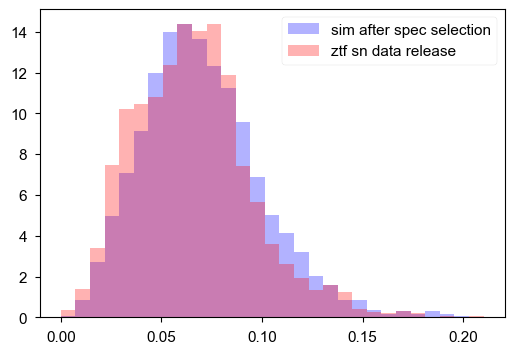

In [23]:
bins=np.linspace(0,0.21,30)
lc_to_plot = lightcurves_after_spec_selection

plt.hist(lc_to_plot['z'],bins=bins,alpha=0.3,density=True,label='sim after spec selection',color='b')
plt.hist(data.redshift,bins=bins,alpha=0.3,density=True,label='ztf sn data release',color='r')

ks = stats.ks_2samp(lc_to_plot['z'],data.redshift)
print(ks)
ad = stats.anderson_ksamp([lc_to_plot['z'],data.redshift])
print(ad)
plt.legend()
plt.show()
# plt.savefig('paper_figs/z_distr.png')

### Fig. 4

KstestResult(statistic=np.float64(0.04330147301893499), pvalue=np.float64(0.0041477507106330745), statistic_location=np.float64(0.0849729), statistic_sign=np.int8(-1))
Anderson_ksampResult(statistic=np.float64(4.475184762549837), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.0053786808651971295)
KLD= 0.01936525880083641


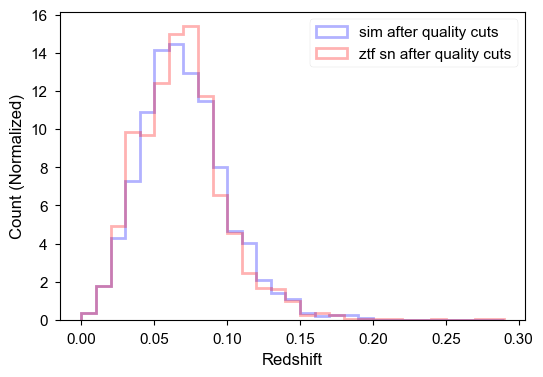

In [90]:
bins=np.linspace(0,0.29,30)
lc_to_plot = lightcurves_after_quality_cut

plt.hist(lc_to_plot['z'],bins=bins,alpha=0.3,density=True,
         histtype='step',label='sim after quality cuts',color='b',lw=2)
plt.hist(data.loc[data.lccoverage_flag==1].redshift,bins=bins,alpha=0.3,density=True,
         histtype='step',label='ztf sn after quality cuts',color='r', lw=2)
ks = stats.ks_2samp(lc_to_plot['z'],data.loc[data.lccoverage_flag==1].redshift)
print(ks)
ad = stats.anderson_ksamp([lc_to_plot['z'],data.loc[data.lccoverage_flag==1].redshift])
print(ad)

p1,_ = np.histogram(lc_to_plot['z'],bins=bins,density=True)
p2,_ = np.histogram(data.loc[data.lccoverage_flag==1].redshift,bins=bins,density=True)
p1 = np.clip(p1, 1.e-8, None)
p2 = np.clip(p2, 1.e-8, None)
print("KLD=",stats.entropy(p1,p2))

plt.legend()
plt.xlabel('Redshift')
plt.ylabel('Count (Normalized)')
plt.savefig('paper_figs/z_distr.png')

In [25]:
data.columns

Index(['Unnamed: 0', 'ztfname', 'redshift', 'redshift_err', 'source', 't0',
       'x0', 'x1', 'c', 't0_err', 'x0_err', 'x1_err', 'c_err', 'cov_t0_x0',
       'cov_t0_x1', 'cov_t0_c', 'cov_x0_x1', 'cov_x0_c', 'cov_x1_c', 'mwebv',
       'mwr_v', 'mwebv_err', 'fitprob', 'ra', 'dec', 'sn_type', 'sub_type',
       'lccoverage_flag', 'fitquality_flag', 'iau_name', 'frac_fitted',
       'ra_host', 'dec_host', 'mass', 'mass_err', 'restframe_gz',
       'restframe_gz_err', 'd_dlr'],
      dtype='object')

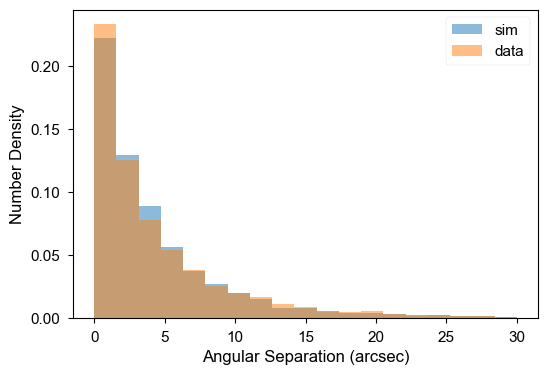

In [26]:
# check host-sn seperation

sep_sim = get_sn_host_sep(lightcurves_after_quality_cut.host_ra, lightcurves_after_quality_cut.host_dec, lightcurves_after_quality_cut.ra, lightcurves_after_quality_cut.dec)
sep_data = get_sn_host_sep(data.ra_host, data.dec_host, data.ra, data.dec)
bins = np.linspace(0,30,20)
plt.hist(sep_sim,bins=bins,alpha=0.5,label='sim',density=True)
plt.hist(sep_data,bins=bins,alpha=0.5,label='data',density=True)
plt.xlabel("Angular Separation (arcsec)")
plt.ylabel("Number Density")
plt.legend()

In [27]:
# data quality flags

# from https://github.com/ZwickyTransientFacility/ztfcosmo/blob/260e136be064708e1238719880ce18844027422e/ztfcosmo/lightcurve.py#L111
# flagout: [list of int or string]
#     flag == 0 means all good, but may not be detected:
    
#     0: no warning 
#     1: flux_err==0 Remove unphysical errors 
#     2: chi2dof>3: Remove extreme outliers 
#     4: cloudy>1: BTS cut 
#     8: infobits>0: BTS cut 
#     16: mag_lim<19.3: Cut applied in Dhawan 2021 
#     32: seeing>3: Cut applied in Dhawan 2021 
#     64: fieldid>879: Recommended IPAC cut 
#     128: moonilf>0.5: Recommended IPAC cut 
#     256: has_baseline>1: Has a valid baseline correction 
#     512: airmass>2: Recommended IPAC cut 
#     1024: flux/flux_err>=5: Nominal detection

In [28]:
# ztf sndr2 flags
# sn_type SNIa classification 
# sub_type sub classification if any. 
# lccoverage_flag passes the good sampling cut (bool,Table1) 
# fitquality_flag passes all other Basic cuts (bool,Table1)

In [29]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

In [30]:
#calculate this first
lcdata["lc.pass_flag_filter"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[8],flags_to_include=[])
lcdata["lc.pass_detection"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[],flags_to_include=[1024])

lcdata['lc.snr'] = lcdata['lc.flux']/lcdata['lc.flux_err']
lcdata["lc.pass_snr_detection"] = lcdata["lc.snr"] > 5

In [31]:
def calculate_median_cadence(mjd):
    mjd = np.sort(mjd)
    mjd_diff = np.diff(mjd)
    return np.median(mjd_diff)

In [32]:
#caculate nobs, ndetections

for f in "gri":
    lc_to_show = lightcurves_after_spec_selection.dropna(subset="lc")
    lc_to_show = lc_to_show.query("lc.infobits == 0").dropna(subset="lc")    
    data_to_show = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
    data_to_show["lc.detection_flag"] = data_to_show["lc.pass_snr_detection"]
    
    t_min_obslog,t_max_obslog = 58288.171875, 59273.5546875
    data_to_show = data_to_show.query(f"lc.mjd>= {t_min_obslog} & lc.mjd <= {t_max_obslog}").dropna(subset="lc")

    lc_to_show["lc.phase"] =  (lc_to_show["lc.mjd"] - lc_to_show["t0"])/(1.+lc_to_show["z"])
    data_to_show["lc.phase"] = (data_to_show["lc.mjd"] - data_to_show["t0"])/(1.+data_to_show["redshift"])
    
    lc_to_show["lc"] = lc_to_show["lc"].nest[lc_to_show["lc.filter"] == f]
    data_to_show["lc"] = data_to_show["lc"].nest[data_to_show["lc.filter"] == "ztf"+f]

    nobs_sim = lc_to_show['lc.mjd'].count()
    nobs_data = data_to_show['lc.mjd'].count()

    ndet_sim = lc_to_show.query("lc.detection_flag == True").dropna(subset="lc")['lc.mjd'].count()
    ndet_data = data_to_show.query("lc.detection_flag == True").dropna(subset="lc")['lc.mjd'].count()
 
    ndet_sim_window = lc_to_show.query("lc.detection_flag == True & lc.phase < 50 & lc.phase > -20").dropna(subset="lc")['lc.mjd'].count()
    ndet_data_window = data_to_show.query("lc.detection_flag == True & lc.phase < 50 & lc.phase > -20").dropna(subset="lc")['lc.mjd'].count()
    
    avg_nobs_sim = nobs_sim/len(lc_to_show)
    avg_nobs_data = nobs_data/len(data_to_show)
    avg_ndet_sim = ndet_sim/len(lc_to_show)
    avg_ndet_data = ndet_data/len(data_to_show)
    avg_ndet_sim_win = ndet_sim_window/len(lc_to_show)
    avg_ndet_data_win = ndet_data_window/len(data_to_show)
    
    avg_cadence_sim = lc_to_show.reduce(calculate_median_cadence,"lc.mjd")
    avg_cadence_data = data_to_show.reduce(calculate_median_cadence,"lc.mjd")
    
    avg_cadence_sim_det = lc_to_show.query("lc.detection_flag==True").reduce(calculate_median_cadence,"lc.mjd")
    avg_cadence_data_det = data_to_show.query("lc.detection_flag==True").reduce(calculate_median_cadence,"lc.mjd")

    print(f"filter = {f}")
    print("     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   ")

    print(f" sim |{len(lc_to_show)} | {nobs_sim} | {ndet_sim}  | {ndet_sim_window} | {avg_nobs_sim:.2f}  | {avg_ndet_sim:.2f} | {avg_ndet_sim_win:.2f} |{avg_cadence_sim.median()[0]:.2f} | {avg_cadence_sim_det.median()[0]:.2f}")
    print(f" data|{len(data_to_show)} | {nobs_data} | {ndet_data}  | {ndet_data_window} | {avg_nobs_data:.2f} | {avg_ndet_data:.2f} | {avg_ndet_data_win:.2f} |{avg_cadence_data.median()[0]:.2f} |{avg_cadence_data_det.median()[0]:.2f}")


filter = g
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4733 | 1559630 | 105375  | 94694 | 329.52  | 22.26 | 20.01 |1.04 | 2.03
 data|3592 | 1290586 | 104081  | 85181 | 359.29 | 28.98 | 23.71 |1.02 |1.99
filter = r
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4733 | 2105709 | 188070  | 156017 | 444.90  | 39.74 | 32.96 |0.98 | 1.13
 data|3592 | 1676667 | 165462  | 133993 | 466.78 | 46.06 | 37.30 |0.96 |1.10
filter = i
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4733 | 302089 | 24022  | 20592 | 63.83  | 5.08 | 4.35 |3.96 | 4.01
 data|3592 | 228228 | 18237  | 15808 | 63.54 | 5.08 | 4.40 |3.99 |4.58


array([[<Axes: title={'center': '0'}>]], dtype=object)

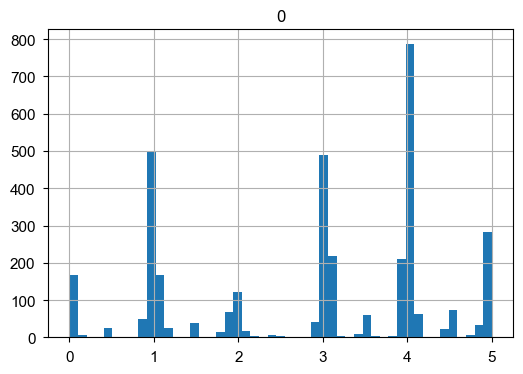

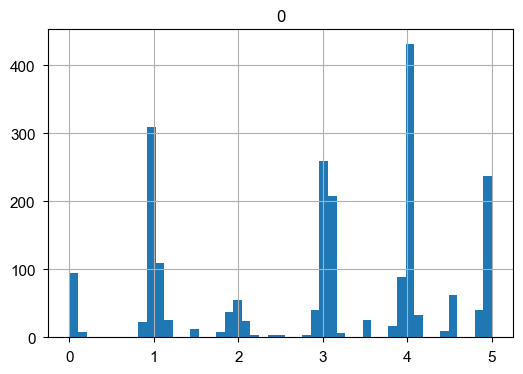

In [33]:
avg_cadence_sim.hist(bins=np.linspace(0,5))
avg_cadence_data.hist(bins=np.linspace(0,5))

array([[<Axes: title={'center': '0'}>]], dtype=object)

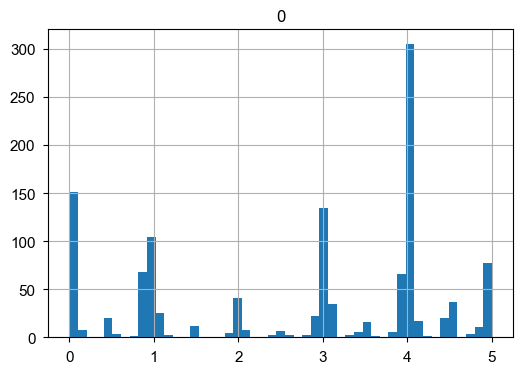

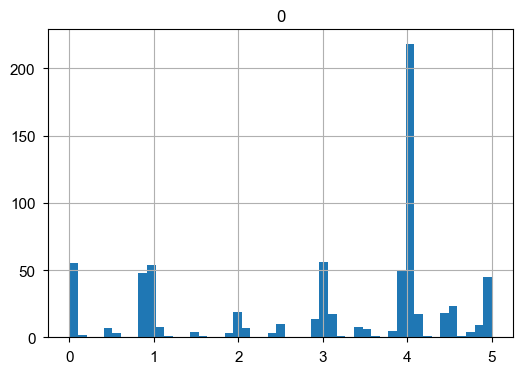

In [34]:
avg_cadence_sim_det.hist(bins=np.linspace(0,5))
avg_cadence_data_det.hist(bins=np.linspace(0,5))

### Fig. 7

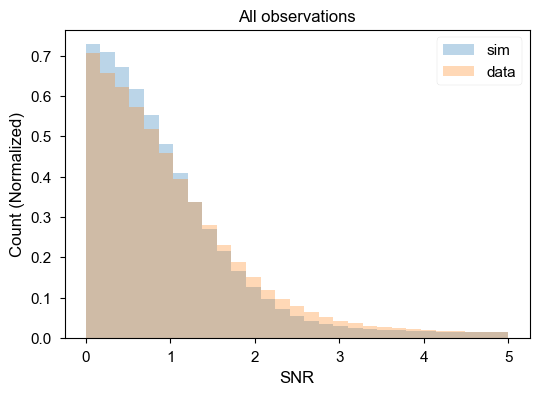

In [35]:
lc_to_plot = lightcurves.loc[lightcurves_after_spec_selection.index]
lcdata_plot = lcdata

bins = np.linspace(0,5,30)

plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,alpha=0.3,density=True,labels=['sim','data'])
plt.xlabel('SNR')
plt.ylabel('Count (Normalized)')
plt.title('All observations')
plt.savefig('paper_figs/snr_allobs.png')

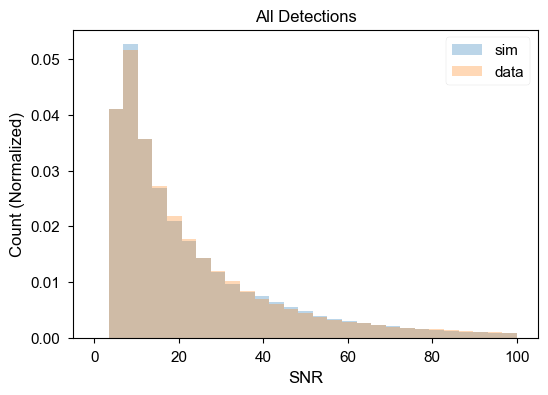

In [36]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

# lcdata["lc.pass_flag_filter"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8,16,32,64,128,256,512],flags_to_include=[1024])
lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_detection == True & lc.pass_snr_detection == True").dropna(subset="lc")

bins = np.linspace(0,100,30)

plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,alpha=0.3,density=True,labels=['sim','data'])
plt.xlabel('SNR')
plt.ylabel('Count (Normalized)')
plt.title('All Detections')
plt.savefig('paper_figs/snr_alldetection.png')

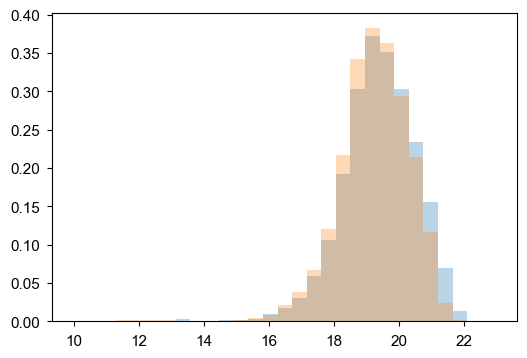

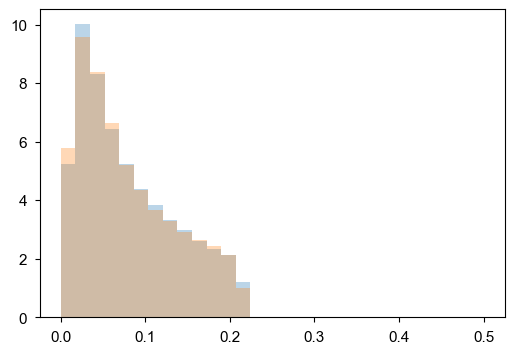

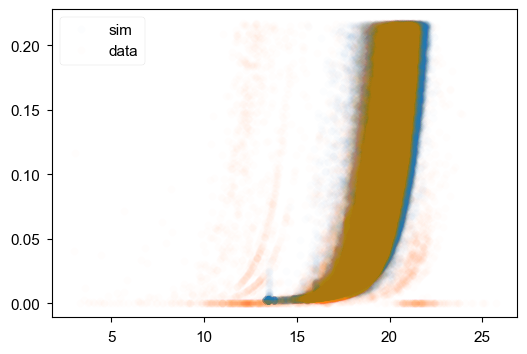

In [37]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_detection == True & lc.pass_snr_detection == True").dropna(subset="lc")

lc_to_plot['lc.mag'],lc_to_plot['lc.magerr'] = convert_flux_to_mag(lc_to_plot['lc.flux'],lc_to_plot['lc.fluxerr'],zp=31.4)
lcdata_plot['lc.mag'],lcdata_plot['lc.magerr'] = convert_flux_to_mag(lcdata_plot['lc.flux'],lcdata_plot['lc.flux_err'],zp=30.)

plot_mag_vs_magerr(lc_to_plot,lcdata_plot)

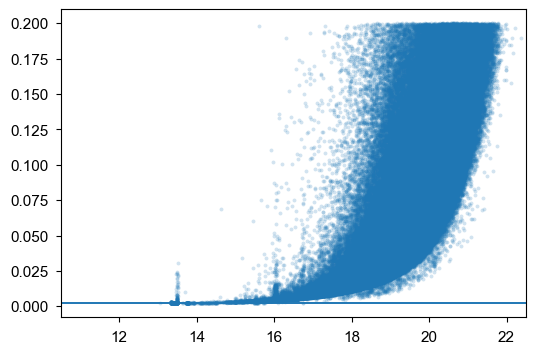

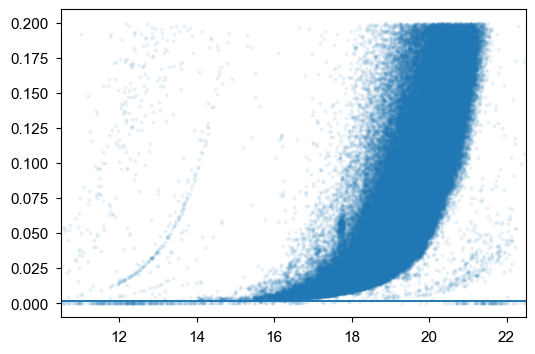

In [38]:
idx = lc_to_plot["lc.filter"] == 'r'
plt.plot(lc_to_plot["lc.mag"][idx],lc_to_plot["lc.magerr"][idx]/(2.5/np.log(10.)),'.',alpha=0.2)
plt.xlim((10.5,22.5))
plt.axhline(y=0.002)
plt.show()
idx = lcdata_plot["lc.filter"] == 'ztfr'
plt.plot(lcdata_plot["lc.mag"][idx],lcdata_plot["lc.magerr"][idx]/(2.5/np.log(10.)),'.',alpha=0.1)
plt.xlim((10.5,22.5))
plt.axhline(y=0.002)

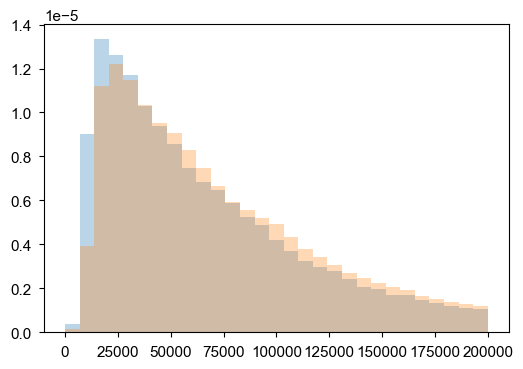

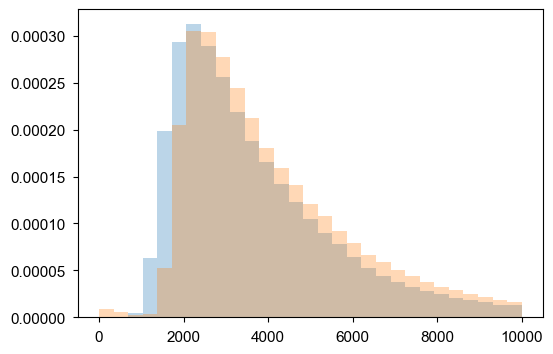

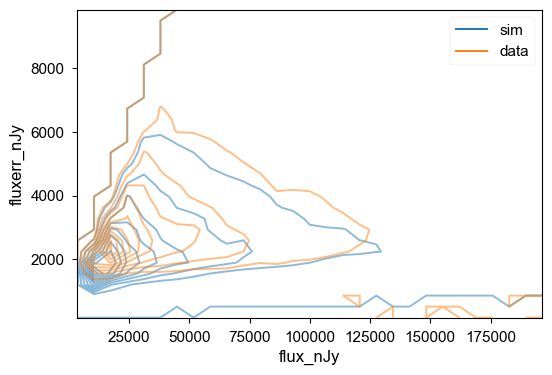

In [39]:
plot_flux_vs_fluxerr(lc_to_plot,lcdata_plot)

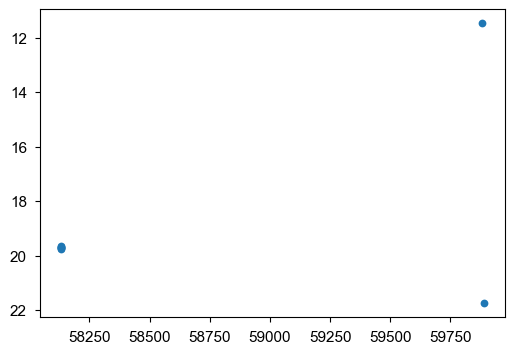

ZTF18aaadqua
           mjd filter          flux      flux_err    ZP  flag        mag  \
0  58131.08391   ztfg  4.515910e+04  1.326363e+03  30.0  1024  18.363137   
1  58131.10464   ztfg  4.830356e+04  1.131343e+03  30.0  1024  18.290052   
2  58131.12514   ztfg  4.959392e+04  1.180396e+03  30.0  1024  18.261429   
3  58131.14986   ztfg  4.664860e+04  1.164231e+03  30.0  1024  18.327903   
4  58131.17133   ztfg  4.866611e+04  1.365833e+03  30.0  1024  18.281933   
5  58131.21061   ztfg  4.767814e+04  1.494936e+03  30.0  1024  18.304202   
6  59880.30610   ztfi  9.399034e+07  3.444647e+06  30.0  1072  10.067292   
7  59887.23223   ztfi  7.215902e+03  1.420117e+02  30.0  1329  20.354273   

   mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0  0.03189       554  29.0  -1069.43221    36.30847        1.0            0   
1  0.02543       554  29.0  -1069.43221    36.30847        1.0            0   
2  0.02584       554  29.0  -1069.43221    36.30847        1.0   

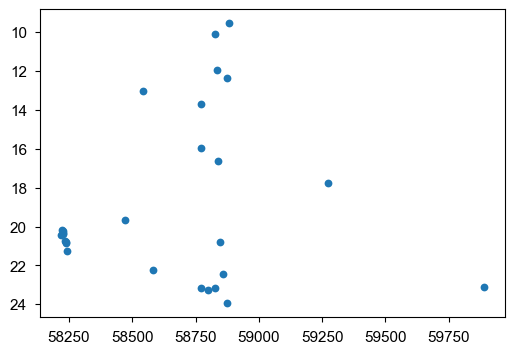

ZTF18aahrdpu
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58217.22177   ztfr  2.486171e+04  2.771386e+03  30.0  1024  19.011172   
1   58221.20057   ztfr  3.036546e+04  3.490186e+03  30.0  1088  18.794050   
2   58224.17316   ztfr  2.887696e+04  5.427528e+03  30.0  1024  18.848621   
3   58227.15965   ztfr  2.645057e+04  2.737058e+03  30.0  1024  18.943912   
4   58227.17402   ztfg  2.519725e+04  9.052304e+02  30.0  1024  18.996617   
5   58233.22682   ztfg  1.839015e+04  1.603770e+03  30.0  1280  19.338537   
6   58236.15441   ztfg  1.699076e+04  1.633835e+03  30.0  1280  19.424468   
7   58236.20639   ztfg  1.731874e+04  1.833710e+03  30.0  1280  19.403710   
8   58243.15490   ztfr  1.122648e+04  1.805575e+03  30.0  1088  19.874391   
9   58472.41248   ztfr  4.887111e+04  1.737634e+02  30.0  1329  18.277369   
10  58540.22120   ztfr  2.243465e+07  1.179954e+06  30.0  1072  11.622702   
11  58582.22013   ztfr  4.604271e+03  1.754563e+02  30.0  1073 

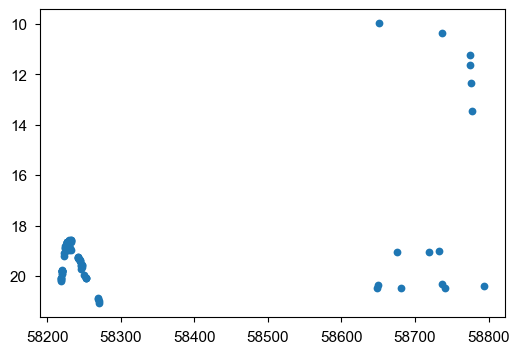

ZTF18aajtlbf
            mjd filter          flux    flux_err    ZP  flag        mag  \
0   58218.39372   ztfr  3.458000e+04  1018.21674  30.0  1024  18.652938   
1   58218.41253   ztfr  3.036280e+04   991.59864  30.0  1024  18.794145   
..          ...    ...           ...         ...   ...   ...        ...   
81  58777.16866   ztfg  1.517867e+07   309.47254  30.0  1089  12.046916   
82  58793.10081   ztfr  2.562890e+04   140.91285  30.0  1281  18.978175   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.03197       825   4.0 -22932.44373   121.05652    1.00000            0   
1   0.03546       825   4.0 -22932.44373   121.05652    1.00000            0   
..      ...       ...   ...          ...         ...        ...          ...   
81  0.00002       825   4.0 -88257.33529   170.00644    1.67902            0   
82  0.00597       825   4.0 -22932.44373   121.05652    1.00000            0   

    pass_flag_filter  pass_detection           snr  pas

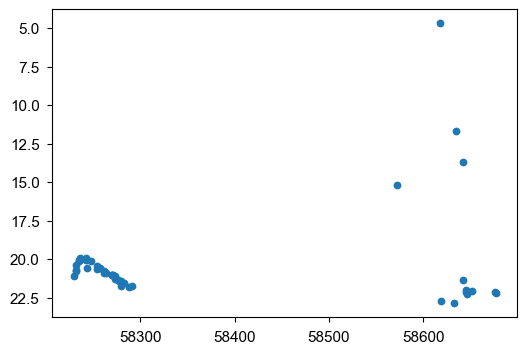

ZTF18aaovbiy
            mjd filter         flux    flux_err    ZP  flag        mag  \
0   58229.31649   ztfg  13442.28341   652.49118  30.0  1024  19.678817   
1   58232.33273   ztfi  17661.47103  1248.57954  30.0  1280  19.382433   
..          ...    ...          ...         ...   ...   ...        ...   
45  58676.21878   ztfr   4925.63594   363.25279  30.0  1313  20.768844   
46  58677.23890   ztfr   4726.28395   363.36680  30.0  1313  20.813700   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.05270       631  58.0  -7801.85250    68.57577        1.0            0   
1   0.07676       631  58.0  -5271.47154   128.12864        1.0            0   
..      ...       ...   ...          ...         ...        ...          ...   
45  0.08007      1675  20.0  -1810.56247   357.14315        1.0            0   
46  0.08347      1675  20.0  -1810.56247   357.14315        1.0            0   

    pass_flag_filter  pass_detection        snr  pass_snr_det

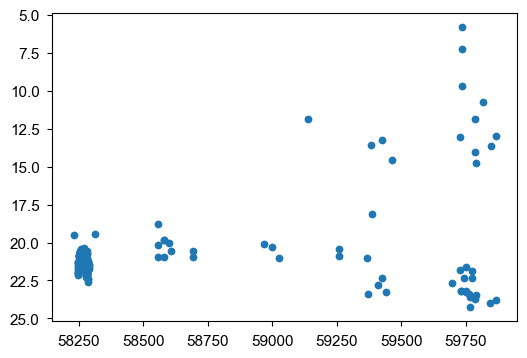

ZTF18aashtth
             mjd filter          flux    flux_err    ZP  flag        mag  \
0    58230.45958   ztfr  5.587708e+04  3343.64881  30.0  1026  18.131916   
1    58246.33757   ztfg  5.008439e+03   844.97945  30.0  1024  20.750744   
..           ...    ...           ...         ...   ...   ...        ...   
203  59867.12227   ztfg  1.081001e+03    79.09874  30.0  1025  22.415435   
204  59867.15422   ztfr  2.376727e+07    83.72696  30.0  1025  11.560052   

     mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0    0.06497       635  32.0   -889.93482    52.03325        1.0            0   
1    0.18318       635  32.0    167.23896    43.98385        1.0            0   
..       ...       ...   ...          ...         ...        ...          ...   
203  0.07945       635  32.0    167.23896    43.98385        1.0            0   
204  0.00000       635  32.0   -889.93482    52.03325        1.0            0   

     pass_flag_filter  pass_detection      

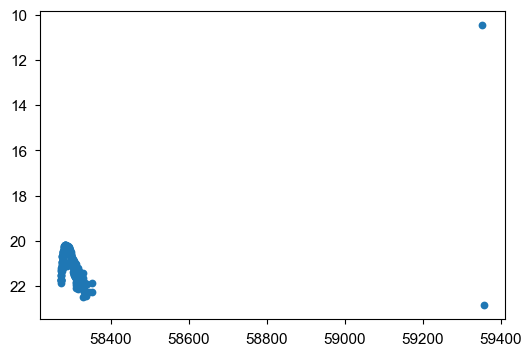

ZTF18aaxqyki
             mjd filter          flux   flux_err    ZP  flag        mag  \
0    58272.21381   ztfg  7.360275e+03  517.99030  30.0  1024  20.332765   
1    58272.24263   ztfg  7.462095e+03  531.03335  30.0  1024  20.317848   
..           ...    ...           ...        ...   ...   ...        ...   
252  59352.30538   ztfr  2.335908e+08   76.94883  30.0  1025   9.078861   
253  59355.36587   ztfr  2.615798e+03   42.27286  30.0  1351  21.455989   

     mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0    0.07641       794  58.0    182.18167    51.81879        1.0            0   
1    0.07727       794  58.0    182.18167    51.81879        1.0            0   
..       ...       ...   ...          ...         ...        ...          ...   
252  0.00000       794  58.0    277.24827    42.27286        1.0            0   
253  0.01755       794  58.0    277.24827    42.27286        1.0            0   

     pass_flag_filter  pass_detection           s

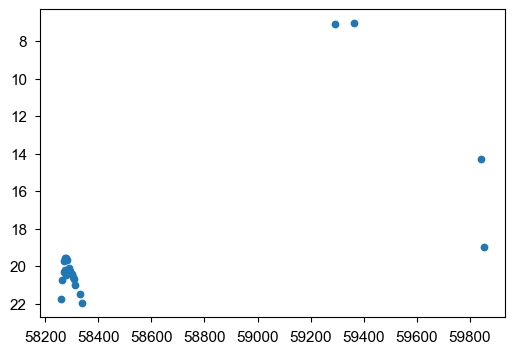

ZTF18aaxxfah
            mjd filter          flux      flux_err    ZP  flag        mag  \
0   58258.25159   ztfr  7.198084e+03  9.507730e+02  30.0  1024  20.356958   
1   58261.29616   ztfr  1.804775e+04  1.791228e+03  30.0  1344  19.358943   
2   58270.28991   ztfg  2.661603e+04  2.099018e+03  30.0  1024  18.937142   
3   58270.31704   ztfr  4.764090e+04  1.419003e+03  30.0  1024  18.305050   
4   58273.25328   ztfg  2.933809e+04  1.631617e+03  30.0  1024  18.831420   
5   58273.31572   ztfr  5.504164e+04  9.296289e+02  30.0  1024  18.148272   
6   58279.25275   ztfr  5.329189e+04  7.285204e+02  30.0  1024  18.183347   
7   58279.29507   ztfg  2.292171e+04  1.677752e+03  30.0  1024  19.099382   
8   58282.20990   ztfr  4.793173e+04  7.519965e+02  30.0  1024  18.298442   
9   58288.25355   ztfr  3.299385e+04  8.294896e+02  30.0  1024  18.703918   
10  58294.25106   ztfr  2.825176e+04  1.535471e+03  30.0  1280  18.872386   
11  58300.17373   ztfr  2.414112e+04  1.315056e+03  30.0  1024 

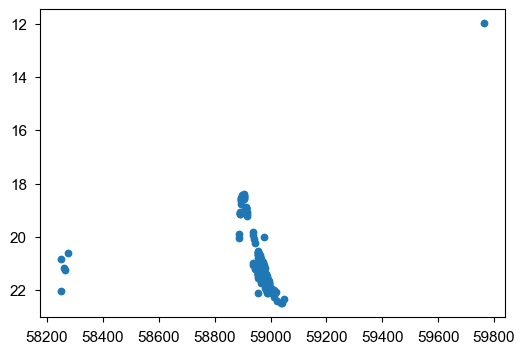

ZTF18aaybfsd
             mjd filter          flux    flux_err    ZP  flag        mag  \
0    58249.37209   ztfg  5.499039e+03  1049.41044  30.0  1092  20.649283   
1    58249.41186   ztfr  1.679762e+04  2180.34374  30.0  1092  19.436880   
..           ...    ...           ...         ...   ...   ...        ...   
155  59049.20168   ztfg  4.172451e+03   499.86065  30.0  1024  20.949022   
156  59762.22933   ztfg  5.800724e+07    85.65459  30.0  1025  10.591295   

     mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0    0.20720       721  13.0    285.82130    72.94913        1.0            0   
1    0.14093       721  13.0    -55.04689    90.43643        1.0            0   
..       ...       ...   ...          ...         ...        ...          ...   
155  0.13007       720   0.0   -367.33000    59.86405        1.0            0   
156  0.00000       720   0.0   -367.33000    59.86405        1.0            0   

     pass_flag_filter  pass_detection      

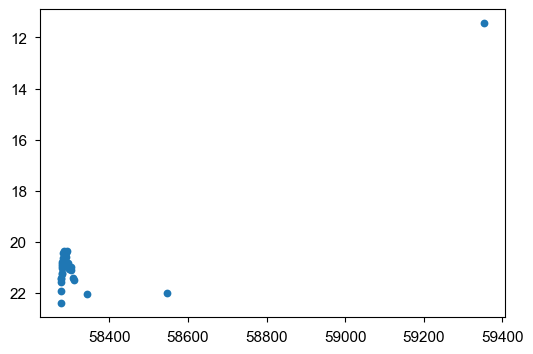

ZTF18aazhwnh
            mjd filter          flux   flux_err    ZP  flag        mag  \
0   58276.25372   ztfg  8.593520e+03  454.08824  30.0  1024  20.164572   
1   58276.29600   ztfr  6.271340e+03  843.94627  30.0  1024  20.506599   
..          ...    ...           ...        ...   ...   ...        ...   
30  58547.51909   ztfr  5.699329e+03  835.86358  30.0  1024  20.610441   
31  59352.36713   ztfi  9.568696e+07  311.25933  30.0  1025  10.047868   

    mag_err  field_id  rcid  flux_offset  offset_unc  err_scale  in_baseline  \
0   0.05737       631   8.0  -6497.84242    74.40386    1.09402            0   
1   0.14611       631   8.0   2001.64368    60.00743    1.27276            0   
..      ...       ...   ...          ...         ...        ...          ...   
30  0.15923       631   8.0   2001.64368    60.00743    1.27276            0   
31  0.00000       631   8.0  -3188.71266   197.53975    1.36119            0   

    pass_flag_filter  pass_detection            snr  pass_snr

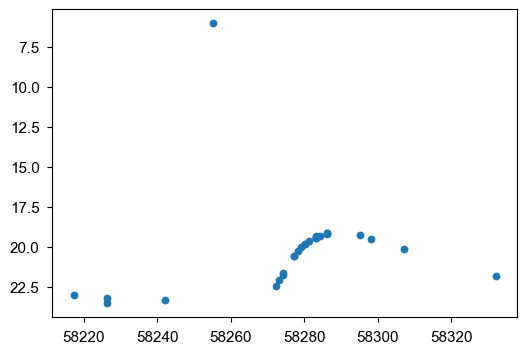

ZTF18aazxthg
            mjd filter          flux    flux_err    ZP  flag        mag  \
0   58217.28442   ztfr  2.318059e+03     0.00000  30.0  1043  21.587189   
1   58226.27228   ztfr  1.398046e+03    61.80585  30.0  1041  22.136197   
2   58226.31350   ztfr  1.922945e+03    61.80585  30.0  1041  21.790083   
3   58242.27253   ztfr  1.675872e+03     0.00000  30.0  1043  21.939398   
4   58255.23243   ztfr  1.402946e+10    30.90295  30.0  1041   4.632397   
5   58272.22986   ztfg  3.900731e+03   458.59119  30.0  1024  21.022135   
6   58273.24029   ztfg  5.351354e+03   469.83031  30.0  1024  20.678841   
7   58274.25405   ztfg  7.215220e+03   400.34765  30.0  1024  20.354376   
8   58274.25558   ztfg  8.053602e+03   437.87145  30.0  1024  20.235025   
9   58277.21743   ztfg  2.123397e+04   501.66615  30.0  1024  19.182422   
10  58277.21834   ztfg  2.110272e+04   513.03052  30.0  1024  19.189154   
11  58278.21062   ztfg  2.867585e+04   675.71312  30.0  1024  18.856209   
12  58279.21

In [40]:
# check about the outliers in data
maglim = mag2flux(12)
idx = lcdata_plot.query(f'lc.flux > {maglim}').dropna(subset='lc').index
outlier = lcdata_plot.loc[idx]
for i in range(0,np.min([10,len(outlier)])):
    plt.plot(outlier.iloc[i]['lc']['mjd'],flux2mag(outlier.iloc[i]['lc']['flux']),'o')
    plt.ylim(plt.ylim()[::-1])
    plt.show()
    print(outlier.iloc[i]['ztfname'])
    print(outlier.iloc[i]['lc'])

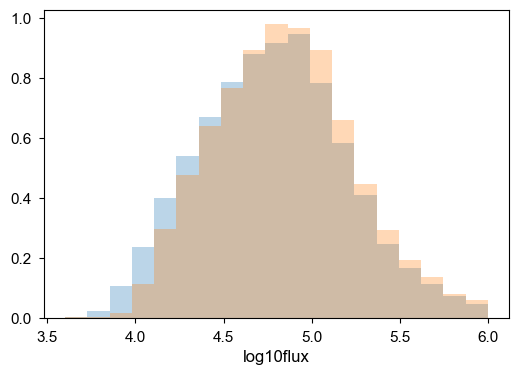

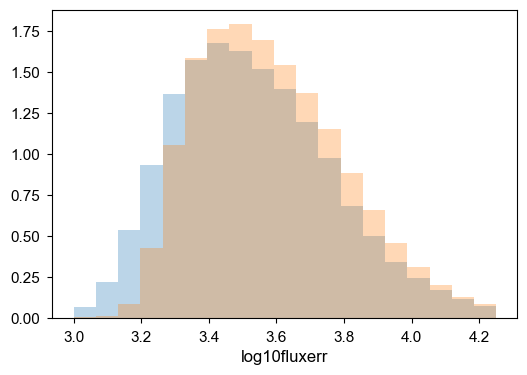

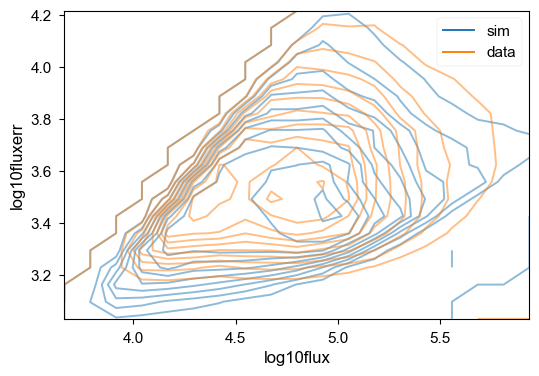

In [41]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_detection == True & lc.pass_snr_detection == True").dropna(subset="lc")

plot_logflux_vs_logfluxerr(lc_to_plot, lcdata_plot)

### Fig. 8

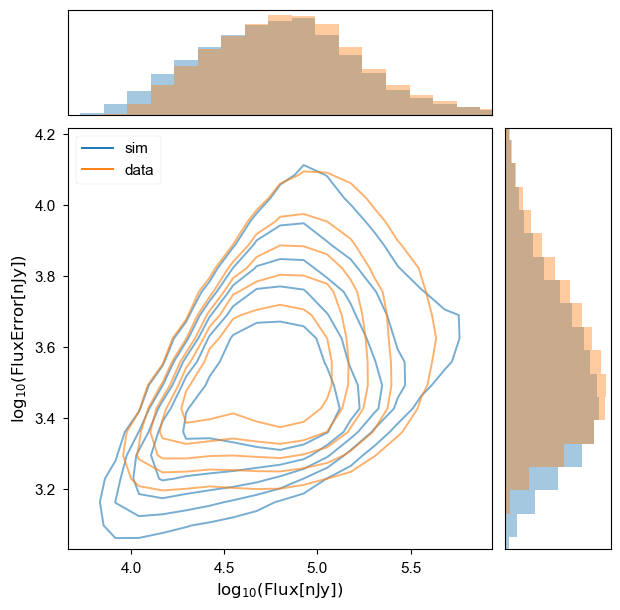

In [42]:
plot_logflux_vs_logfluxerr_corner(lc_to_plot, lcdata_plot, smooth_sigma=0.6)
plt.savefig('paper_figs/logflux_contour.png')

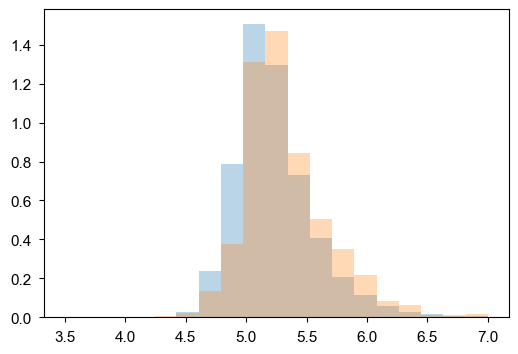

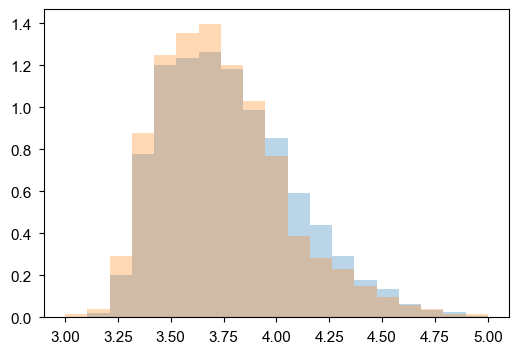

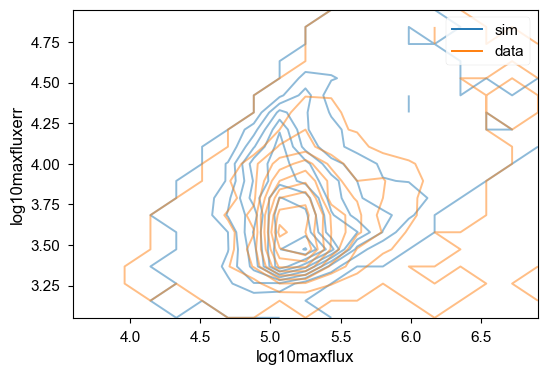

In [43]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_detection == True & lc.pass_snr_detection == True").dropna(subset="lc")

plot_logmaxflux_vs_logmaxfluxerr(lc_to_plot,lcdata_plot)

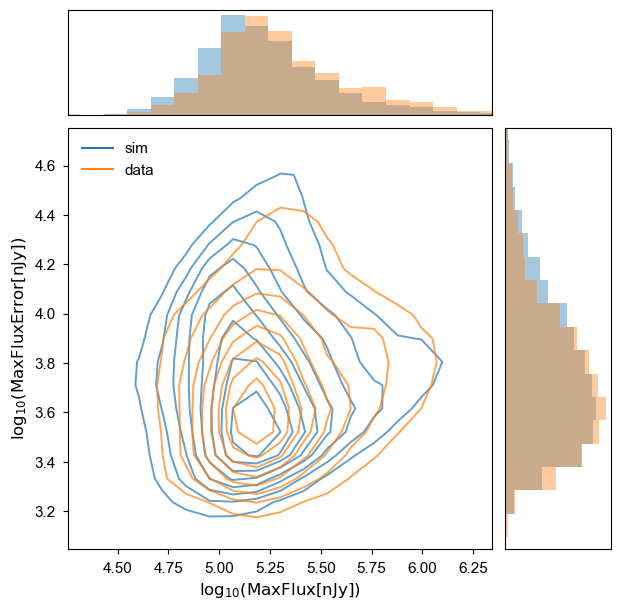

In [44]:
plot_logmaxflux_vs_logmaxfluxerr_corner(lc_to_plot,lcdata_plot,n_levels=10,smooth_sigma=0.8)
plt.savefig('paper_figs/logmaxflux_contour.png')

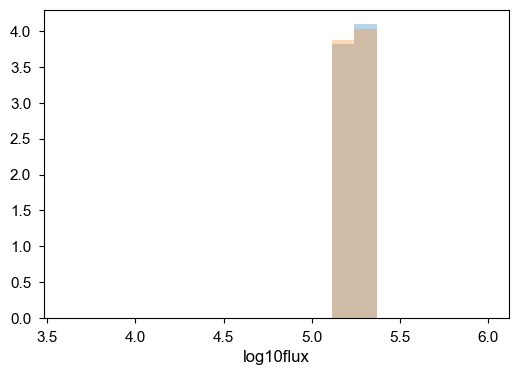

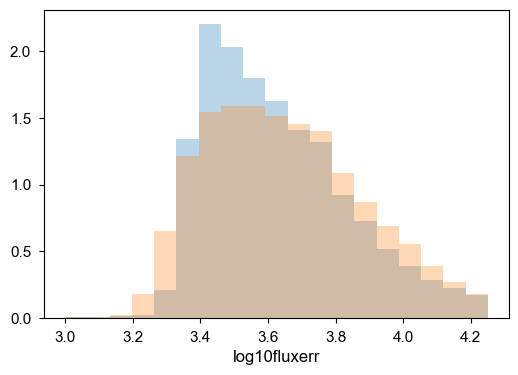

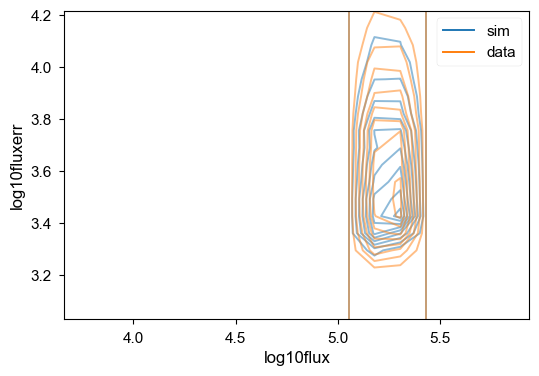

In [45]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_detection == True & lc.pass_snr_detection == True").dropna(subset="lc")

lc_to_plot['lc.mag'],lc_to_plot['lc.magerr'] = convert_flux_to_mag(lc_to_plot['lc.flux'],lc_to_plot['lc.fluxerr'],zp=31.4)
lcdata_plot['lc.mag'],lcdata_plot['lc.magerr'] = convert_flux_to_mag(lcdata_plot['lc.flux'],lcdata_plot['lc.flux_err'],zp=30.)

lc_to_plot = lc_to_plot.query("lc.mag > 18 & lc.mag < 18.5").dropna(subset="lc")
lcdata_plot = lcdata_plot.query("lc.mag > 18 & lc.mag < 18.5").dropna(subset="lc")

plot_logflux_vs_logfluxerr(lc_to_plot, lcdata_plot)

### Fig. 2

In [46]:
sim_all_x1 = lightcurves['source_x1'].dropna()
sim_all_c = lightcurves['source_c'].dropna()

In [47]:
lc_to_plot = lightcurves_after_spec_selection
sim_x1 = lc_to_plot['source_x1'].dropna()
sim_c = lc_to_plot['source_c'].dropna()

In [48]:
def expo(x, a, b, c):
    x = np.asarray(x)
    y = a * np.exp(b * x) + c
    return y

In [49]:
fx1_parr = np.loadtxt('data/ztf_selection_func_x1.txt')
fc_parr = np.loadtxt('data/ztf_selection_func_c.txt')
fx1_func = lambda x1: expo(x1, *fx1_parr)
fc_func = lambda c: expo(c, *fc_parr)

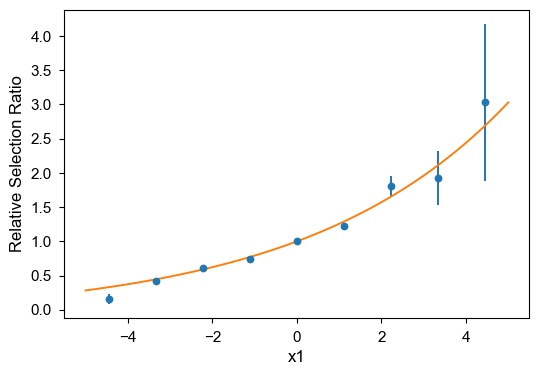

In [50]:
bins = np.linspace(-5,5,10)
x1before,bin_edges,_ = stats.binned_statistic(sim_all_x1,np.ones(len(lightcurves)), statistic='sum', bins=bins)
x1after,bin_edges,_ =  stats.binned_statistic(sim_x1, np.ones(len(lc_to_plot)), statistic='sum', bins=bins)
norm = 1./interp1d((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before)(0)
err = np.sqrt(x1after**2/x1before**3 + x1after/x1before**2)
plt.errorbar((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before*norm,yerr = err*norm, fmt='o')
xplot = np.linspace(-5,5,50)
plt.plot(xplot,fx1_func(xplot)/fx1_func(0))
plt.xlabel('x1')
plt.ylabel('Relative Selection Ratio')
plt.savefig('paper_figs/x1_selection.png')

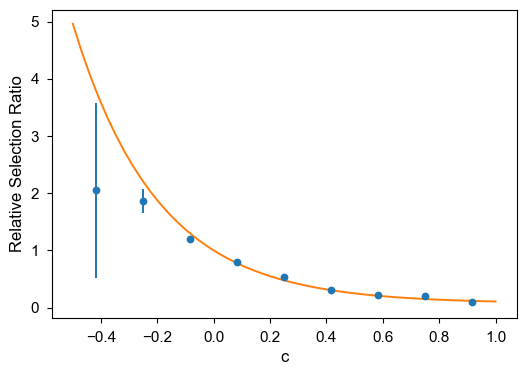

In [51]:
bins = np.linspace(-0.5,1,10)
cbefore,bin_edges,_ = stats.binned_statistic(sim_all_c,np.ones(len(lightcurves)), statistic='sum', bins=bins)
cafter,bin_edges,_ =  stats.binned_statistic(sim_c, np.ones(len(lc_to_plot)), statistic='sum', bins=bins)
norm = 1./interp1d((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore)(0)
err = np.sqrt(cafter**2/cbefore**3 + cafter/cbefore**2)
plt.errorbar((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore*norm,yerr = err*norm, fmt='o')
xplot = np.linspace(-0.5,1,50)
plt.plot(xplot,fc_func(xplot)/fc_func(0))
plt.xlabel('c')
plt.ylabel('Relative Selection Ratio')
plt.savefig('paper_figs/c_selection.png')

Text(0.5, 1.0, 'reduced chisq')

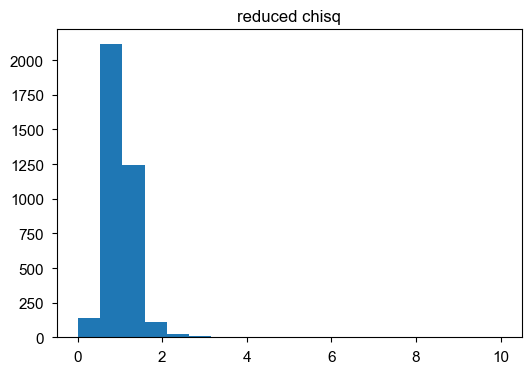

In [52]:
result_df = saltpars
idx = result_df.ndof > 0
plt.hist(result_df[idx].chisq/result_df[idx].ndof,bins=np.linspace(0,10,20))
plt.title('reduced chisq')

In [53]:
lc_to_fit = lightcurves_after_quality_cut

In [54]:
merged = lc_to_fit.merge(result_df,on='id')

In [55]:
len(lc_to_fit), len(merged)

(3665, 3665)

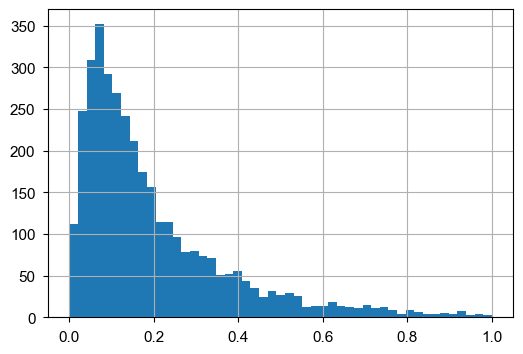

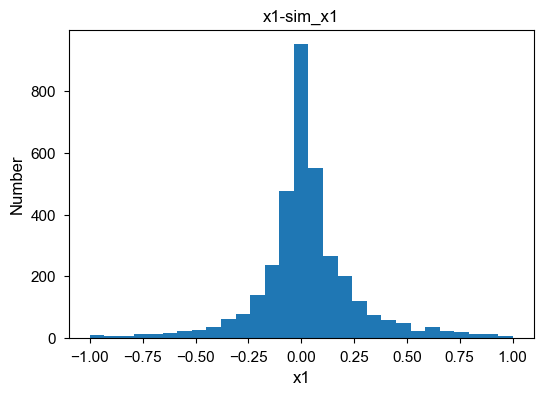

In [56]:
result_df['x1_err'].hist(bins=np.linspace(0,1))
plt.show()

plt.hist((merged.x1-merged.source_x1),bins=np.linspace(-1,1,30))
plt.title('x1-sim_x1')
plt.xlabel('x1')
plt.ylabel('Number')
plt.savefig('paper_figs/x1diff.png')

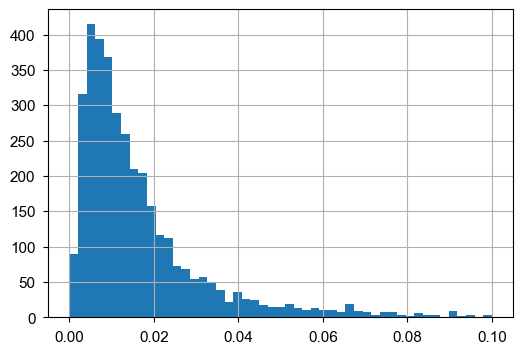

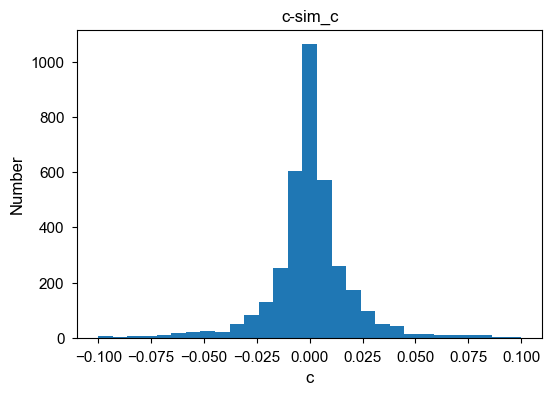

In [57]:
result_df['c_err'].hist(bins=np.linspace(0,0.1))
plt.show()

plt.hist((merged.c-merged.source_c),bins=np.linspace(-0.1,0.1,30))
plt.title('c-sim_c')
plt.xlabel('c')
plt.ylabel('Number')
plt.savefig('paper_figs/cdiff.png')

Text(0.5, 1.0, 'log(x0)-log(sim_x0)')

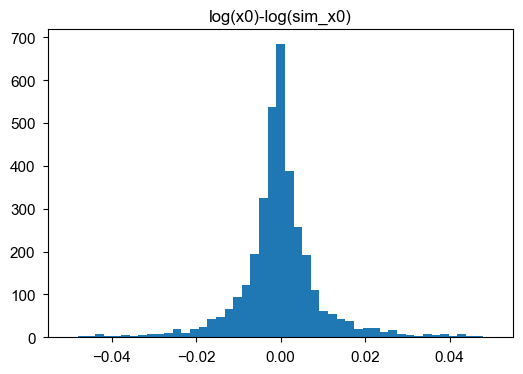

In [58]:
plt.hist(np.log10(merged.x0/merged.source_x0),bins=np.linspace(-0.05,0.05))
plt.title('log(x0)-log(sim_x0)')

### Fig. 5

KstestResult(statistic=np.float64(0.03573387773795799), pvalue=np.float64(0.029989641273768994), statistic_location=np.float64(1.1319559102997565), statistic_sign=np.int8(-1))
KLD= 0.017833010485152605


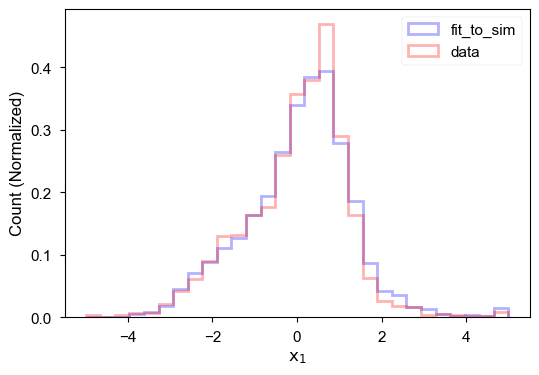

In [80]:
bins=np.linspace(-5,5,30)
# idx = saltpar_cuts
# data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True) & ~data.x1.isna()
idx = np.full(len(result_df), True, dtype=bool)
data_idx = (data.lccoverage_flag == True) & ~data.x1.isna()
    
plt.hist(result_df[idx].x1,bins=bins,density=True,label='fit_to_sim',histtype = 'step',lw = 2, color='blue',alpha=0.3)
plt.hist(data[data_idx].x1,bins=bins,density=True,label='data',histtype = 'step',lw = 2, color='red',alpha=0.3)
plt.legend()
plt.xlabel(r'$\mathrm{x_1}$')
plt.ylabel('Count (Normalized)')

ks = stats.ks_2samp(result_df[idx].x1,data[data_idx].x1)
print(ks)

p1,_ = np.histogram(result_df[idx].x1,bins=bins,density=True)
p2,_ = np.histogram(data[data_idx].x1,bins=bins,density=True)
p1 = np.clip(p1, 1.e-8, None)
p2 = np.clip(p2, 1.e-8, None)
print("KLD=",stats.entropy(p1,p2))

plt.savefig('paper_figs/x1_distr.png')

KstestResult(statistic=np.float64(0.0352728211646569), pvalue=np.float64(0.03338731923882688), statistic_location=np.float64(0.0394800815195265), statistic_sign=np.int8(-1))
KLD= 0.014130591637383212


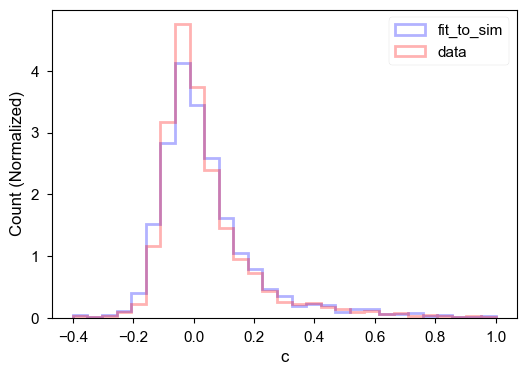

In [85]:
bins=np.linspace(-0.4,1,30)
# idx = saltpar_cuts
# data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True) & ~data.c.isna()
idx = np.full(len(result_df), True, dtype=bool)
data_idx = (data.lccoverage_flag == True) & ~data.x1.isna()

plt.hist(result_df[idx].c,bins=bins,density=True,label='fit_to_sim',histtype = 'step',lw = 2, color='blue',alpha=0.3)
plt.hist(data[data_idx].c,bins=bins,density=True,label='data',histtype = 'step',lw = 2, color='red',alpha=0.3)
plt.legend()
# plt.title('c')
plt.xlabel('c')
plt.ylabel('Count (Normalized)')

ks = stats.ks_2samp(result_df[idx].c,data[data_idx].c)
print(ks)

p1,_ = np.histogram(result_df[idx].c,bins=bins,density=True)
p2,_ = np.histogram(data[data_idx].c,bins=bins,density=True)
p1 = np.clip(p1, 1.e-8, None)
p2 = np.clip(p2, 1.e-8, None)
print("KLD=",stats.entropy(p1,p2))

plt.savefig('paper_figs/c_distr.png')

### Fig. 6

3355
2666
KS: 0.9999999999999868 0.07142857142857142
KLD= 0.07613913854162307


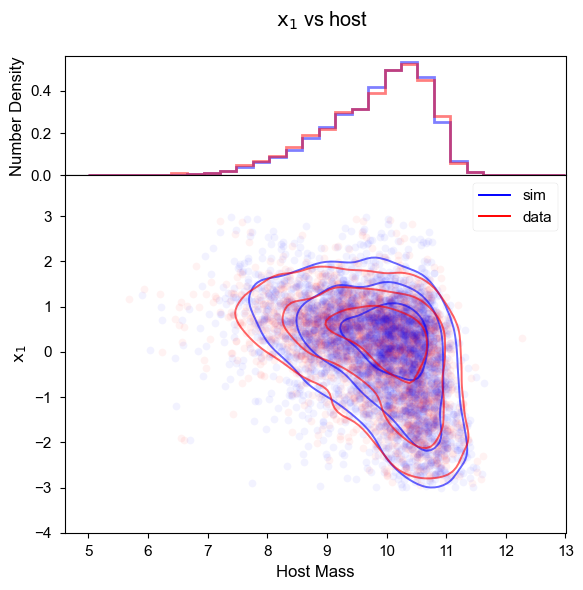

In [84]:
idx = saltpar_cuts
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True)
print(np.sum(idx))
print(np.sum(data_idx))

fig, (ax, ax2) = plt.subplots(2, 1,
                            gridspec_kw={'height_ratios': [1, 3]},   # top is 3x taller than bottom
                            figsize=(6, 6),sharex=True)
hostmass = merged.host_hostmass
x1 = merged.x1
c = merged.c
bins = np.linspace(5,13,30)
ax.hist(hostmass,bins=bins,density=True,label='sim',histtype = 'step',lw = 2, color='blue',alpha=0.5)
ax.hist(data.loc[data.lccoverage_flag == 1].mass,bins=bins,density=True,label='data',histtype = 'step',lw = 2, color='red',alpha=0.5)
ax.set_ylabel('Number Density')

ax2.plot(data[data_idx].mass,data[data_idx].x1,'o',label='ztf sn data release',alpha=0.05,color='red')
ax2.plot(np.array(hostmass)[idx],np.array(x1)[idx],'o',label='sim',alpha=0.05,color='blue')
ax2.legend()
plt.suptitle(r"$\mathrm{x_1}$ vs host",x=0.55)
# plt.show()

# plt.subplot(2,1,2)
bins_x1 = np.linspace(-4,4,15)
bins_hostmass = np.linspace(6,13,15)

data_plot = data[data_idx]
sim_host = np.array(hostmass)
sim_x1 = np.array(x1)

binwidth_host = bins_hostmass[1]-bins_hostmass[0]
binwidth_x1 = bins_x1[1]-bins_x1[0]

sim_count,sim_x_edges,sim_y_edges, _ = stats.binned_statistic_2d(sim_host,sim_x1,
                                             np.ones(len(sim_host)),
                                             statistic='sum',bins=[bins_hostmass,bins_x1])
data_count,data_x_edges,data_y_edges,_ = stats.binned_statistic_2d(data_plot.mass,data_plot.x1,
                                         np.ones(len(data_plot.mass)),
                                         statistic='sum',bins=[bins_hostmass,bins_x1])
sim_x = 0.5* (sim_x_edges[:-1]+sim_x_edges[1:])
sim_y = 0.5* (sim_y_edges[:-1]+sim_y_edges[1:])
data_x = 0.5* (data_x_edges[:-1]+data_x_edges[1:])
data_y = 0.5* (data_y_edges[:-1]+data_y_edges[1:])
# sim_x_plot,sim_y_plot = np.meshgrid(sim_x, sim_y)
# data_x_plot,data_y_plot = np.meshgrid(data_x, data_y)
# CS = ax2.contour(sim_x_plot.T,sim_y_plot.T,sim_count/np.sum(sim_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='blue')
# CS = ax2.contour(data_x_plot.T,data_y_plot.T,data_count/np.sum(data_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='red')
# proxies = [Line2D([],[],color=c) for c in ['blue','red']]
# plt.legend(proxies,['sim', 'data'])
# plt.xlabel('host mass')
# plt.ylabel('x1')
# plt.ylim((-4,4))


# ----------------------------------------------------------------------
# Settings: bin ranges (also used for KDE grid)
# ----------------------------------------------------------------------
bins_x1       = np.linspace(-4, 4, 15)
bins_hostmass = np.linspace(6, 13, 15)

x1_min, x1_max           = bins_x1[0],       bins_x1[-1]
hostmass_min, hostmass_max = bins_hostmass[0], bins_hostmass[-1]

# Resolution of KDE grid
nx = 100
ny = 100

# Mask out NaN/inf
mask_sim = np.isfinite(sim_host) & np.isfinite(sim_x1)
sim_host_clean = sim_host[mask_sim]
sim_x1_clean   = sim_x1[mask_sim]

# Data arrays
data_mass = data_plot.mass.to_numpy()
data_x1   = data_plot.x1.to_numpy()

mask_data = np.isfinite(data_mass) & np.isfinite(data_x1)
data_mass_clean = data_mass[mask_data]
data_x1_clean   = data_x1[mask_data]

# ----------------------------------------------------------------------
# Build KDEs
# ----------------------------------------------------------------------
# Sim KDE
values_sim = np.vstack([sim_host_clean, sim_x1_clean])  # shape (2, N)
kde_sim = stats.gaussian_kde(values_sim)

# Optional: tweak bandwidth (e.g., smoother by factor 1.2)
# kde_sim.set_bandwidth(bw_method=lambda *args, **kwargs: 1.2 * kde_sim.scotts_factor())

# Data KDE
values_data = np.vstack([data_mass_clean, data_x1_clean])
kde_data = stats.gaussian_kde(values_data)

# Optional: tweak bandwidth separately for data
# kde_data.set_bandwidth(bw_method=lambda *args, **kwargs: 1.0 * kde_data.scotts_factor())

# ----------------------------------------------------------------------
# Evaluate KDEs on a common grid
# ----------------------------------------------------------------------
host_grid = np.linspace(hostmass_min, hostmass_max, nx)  # x-axis
x1_grid   = np.linspace(x1_min,       x1_max,       ny)  # y-axis

H, X = np.meshgrid(host_grid, x1_grid)  # H: host mass, X: x1
positions = np.vstack([H.ravel(), X.ravel()])  # shape (2, nx*ny)

Z_sim  = kde_sim(positions).reshape(H.shape)   # PDF sim
Z_data = kde_data(positions).reshape(H.shape)  # PDF data

# ----------------------------------------------------------------------
# Choose contour levels (using percentiles so it adapts to your data)
# ----------------------------------------------------------------------
# You can tune these percentiles for how "central" the contours are
sim_levels_percentiles  = [80, 90, 97]
data_levels_percentiles = [80, 90, 97]

sim_levels  = np.percentile(Z_sim,  sim_levels_percentiles)
data_levels = np.percentile(Z_data, data_levels_percentiles)

# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------

CS_sim = ax2.contour(
    host_grid, x1_grid, Z_sim,
    levels=sim_levels, colors='blue', alpha=0.6
)
CS_data = ax2.contour(
    host_grid, x1_grid, Z_data,
    levels=data_levels, colors='red', alpha=0.6
)

# Legend using proxy artists
proxies = [Line2D([], [], color=c) for c in ['blue', 'red']]
ax2.legend(proxies, ['sim', 'data'])

ax2.set_xlabel('Host Mass')
ax2.set_ylabel(r"$\mathrm{x_1}$")
ax2.set_ylim(-4, 3.9)

fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig('paper_figs/host_x1.png')

p,D = ks2d2s(sim_x,sim_y,data_x,data_y,extra=True)
print("KS:",p,D)

print("KLD=",stats.entropy(Z_sim,Z_data,axis=None))

### Fig. 9

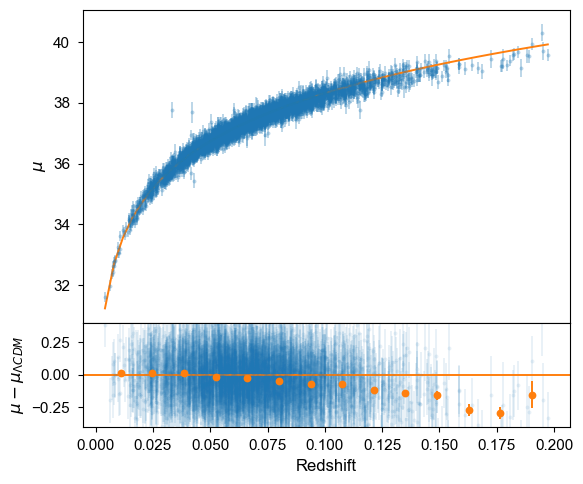

In [62]:
# make HD

x1_hd = result_df.loc[saltpar_cuts,"x1"]
c_hd = result_df.loc[saltpar_cuts,"c"]
x0_hd = result_df.loc[saltpar_cuts,"x0"]
z_hd = result_df.loc[saltpar_cuts,"z"]

x1_err = result_df.loc[saltpar_cuts,"x1_err"]
c_err = result_df.loc[saltpar_cuts,"c_err"]
x0_err = result_df.loc[saltpar_cuts,"x0_err"]

mb_hd = -2.5*np.log10(x0_hd) + 10.635
mb_err = 2.5/np.log(10) * (x0_err/x0_hd)

alpha = ALPHA
beta = BETA
Mb = MAGABS
mu_hd = mb_hd + alpha*x1_hd - beta*c_hd - Mb
mu_err = np.sqrt(mb_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + SIGMA_MAGABS**2)

fig, (ax1, ax2) = plt.subplots(2, 1,
                            gridspec_kw={'height_ratios': [3, 1]},   # top is 3x taller than bottom
                            figsize=(6, 5),sharex=True)

ax1.errorbar(z_hd, mu_hd, yerr=mu_err,fmt='.',alpha=0.3)

z_cosmo = np.linspace(z_hd.min(),z_hd.max(),50)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
mu_cosmo = cosmo.distmod(z_cosmo)
ax1.plot(z_cosmo, mu_cosmo)

ax1.set_ylabel(r'$\mu$')

mures = mu_hd - cosmo.distmod(z_hd).value

# ax2 = plt.subplot(3,1,2, sharex=ax1)
ax2.errorbar(z_hd, mures, yerr=mu_err, fmt='.',alpha=0.1)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax2.axhline(y=0,color=colors[1])
ax2.set_ylim((-0.4,0.4))
ax2.set_ylabel(r'$\mu - \mu_{\Lambda CDM}$')
ax2.set_xlabel('Redshift')

bins= np.linspace(z_hd.min(),z_hd.max(),15)
mures_mean, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='mean', bins= bins
)

mures_std, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='std', bins= bins
)

mures_count, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='count', bins= bins
) 

mures_err = mures_std / np.sqrt(mures_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
ax2.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')

# ax3 = plt.subplot(3,1,3, sharex=ax1)
# ax3.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')
# ax3.axhline(y=0,color=colors[1])
# ax3.set_ylim((-0.2,0.2))
fig.tight_layout()
fig.subplots_adjust(hspace=0)

plt.savefig('paper_figs/HD.png')

In [63]:
print(f"mures RMS: {np.sqrt(np.mean(mures**2))}")
print(f"mures STD: {np.std(mures)}")

mures RMS: 0.18796681259164252
mures STD: 0.18465644186948538


(0.0, 0.2)

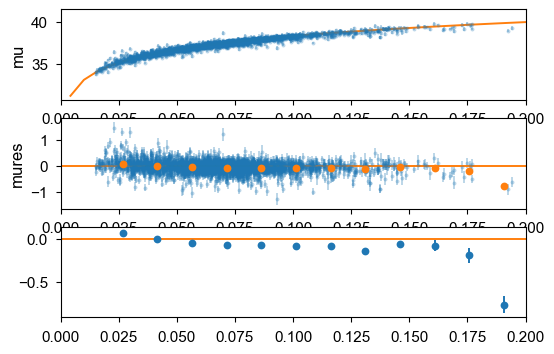

In [64]:
# make HD

data_x1_hd = data[data_idx].x1
data_c_hd = data[data_idx].c
data_x0_hd = data[data_idx].x0
data_z_hd = data[data_idx].redshift

data_x1_err = data[data_idx].x1_err
data_c_err = data[data_idx].c_err
data_x0_err = data[data_idx].x0_err

data_mb_hd = -2.5*np.log10(data_x0_hd) + 10.635
data_mb_err = 2.5/np.log(10) * (data_x0_err/data_x0_hd)

alpha = ALPHA
beta = BETA
Mb = MAGABS
data_mu_hd = data_mb_hd + alpha*data_x1_hd - beta*data_c_hd - Mb
data_mu_err = np.sqrt(data_mb_err**2 + alpha**2*data_x1_err**2 + beta**2*data_c_err**2 + 0.1**2)

ax1 = plt.subplot(3,1,1)

ax1.errorbar(data_z_hd, data_mu_hd, yerr=data_mu_err,fmt='.',alpha=0.3)

data_z_cosmo = np.linspace(data_z_hd.min(),data_z_hd.max(),50)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
data_mu_cosmo = cosmo.distmod(data_z_cosmo)
ax1.plot(data_z_cosmo, data_mu_cosmo)

plt.xlabel('z')
plt.ylabel('mu')

data_mures = data_mu_hd - cosmo.distmod(data_z_hd).value

ax2 = plt.subplot(3,1,2, sharex=ax1)
ax2.errorbar(data_z_hd, data_mures, yerr=data_mu_err, fmt='.',alpha=0.3)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax2.axhline(y=0,color=colors[1])
plt.ylabel('mures')

bins= np.linspace(data_z_hd.min(),data_z_hd.max(),20)
data_mures_mean, bin_edges, _ = stats.binned_statistic(
    data_z_hd, data_mures, statistic='mean', bins= bins
)

data_mures_std, bin_edges, _ = stats.binned_statistic(
    data_z_hd, data_mures, statistic='std', bins= bins
)

data_mures_count, bin_edges, _ = stats.binned_statistic(
    data_z_hd, data_mures, statistic='count', bins= bins
) 

data_mures_err = data_mures_std / np.sqrt(data_mures_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
ax2.errorbar(bin_mean, data_mures_mean, yerr = data_mures_err,fmt='o')

ax3 = plt.subplot(3,1,3, sharex=ax1)
ax3.errorbar(bin_mean, data_mures_mean, yerr = data_mures_err,fmt='o')
ax3.axhline(y=0,color=colors[1])

plt.xlim((0,0.2))

<Axes: >

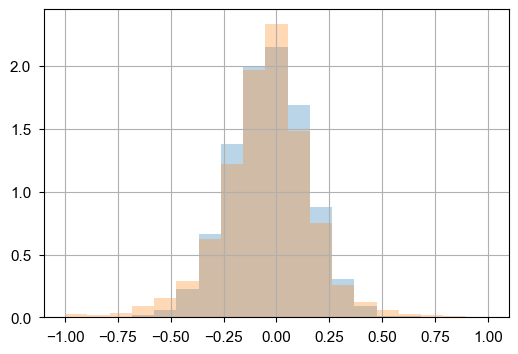

In [65]:
bins = np.linspace(-1,1,20)
mures.hist(bins=bins,alpha=0.3,density=True)
data_mures.hist(bins=bins,alpha=0.3,density=True)

In [66]:
def make_bined_mures_par_plot(cut):
    nbins = 15
    bins_hostmass = np.linspace(7,12,nbins)
    bins_x1 = np.linspace(-3,3,nbins)
    bins_c = np.linspace(-0.2,0.8,nbins)
    bins_arr = [bins_hostmass,bins_x1,bins_c]
    
    fig = plt.figure(figsize=(6,5))
    i=0
    label_map = {'host_hostmass': 'Host Mass',
                 'x1': r'$\mathrm{x_1}$',
                 'c': 'c'}
    for bins, par in zip(bins_arr,['host_hostmass','x1','c']):
        i = i+1 
        fig.add_subplot(3,1,i)
        x_plot = merged[cut][par]
        x_mean, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='mean', bins= bins
        )
        
        x_std, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='std', bins= bins
        )
        
        x_count, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='count', bins= bins
        ) 
    
        x_err = x_std / np.sqrt(x_count)
        
        bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
        plt.errorbar(bin_mean, x_mean, yerr =x_err,fmt='o')
    
        plt.axhline(y=0,ls=':',c='gray')
        plt.xlabel(label_map[par])
        plt.ylabel(r'$\mu - \mu_{\Lambda CDM}$')
    fig.tight_layout()

### Fig. 10

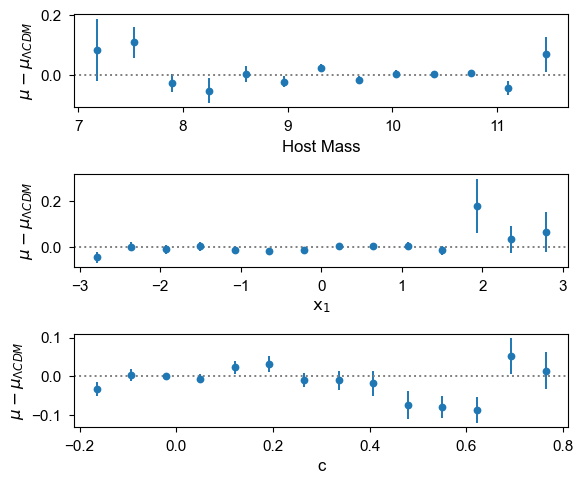

In [67]:
zcut = saltpars["z"]<0.06
allcut = saltpar_cuts & zcut

make_bined_mures_par_plot(allcut)

plt.savefig('paper_figs/mures_vs_par.png')

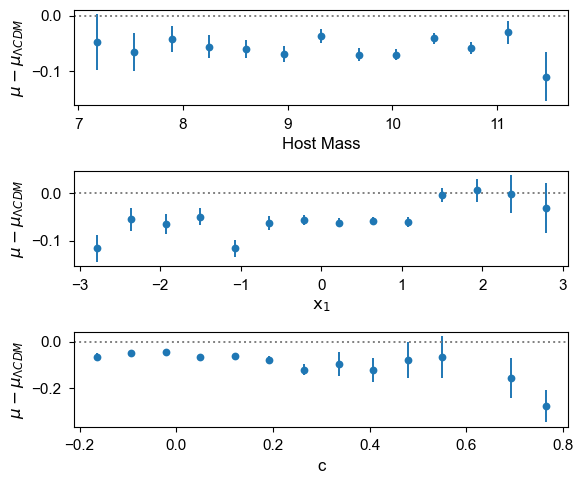

In [68]:
zcut = saltpars["z"]>=0.06
allcut = saltpar_cuts & zcut
make_bined_mures_par_plot(allcut)

Effects maybe simulated

ZTF Photometry "pocket effect" (Fig 2 of ZTF DR2 Overview paper https://arxiv.org/pdf/2409.04346)
<img src="figs/pocket_effect.png" width="400" height="300">
